In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Replace 4 with your desired core count

# Practice on Iris dataset

In [2]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
iris = load_iris() 
X = iris.data
y = iris.target

In [4]:
X.shape

(150, 4)

<Axes: >

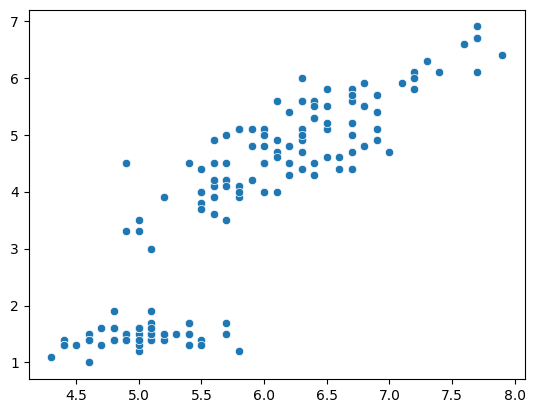

In [5]:
sns.scatterplot(x=X[:, 0], y=X[:, 2])

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

In [7]:
# optional - dimensionality reduction using PCA 
from sklearn.decomposition import PCA 

pca = PCA(n_components=2)

pca_data = scaler.fit_transform(X_scaled)

In [8]:
# Elbow Method
wcss = [] 

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10) 
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_) 

<Axes: >

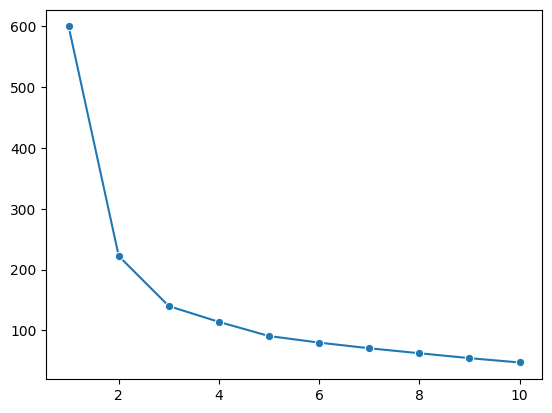

In [9]:
sns.lineplot(x=range(1, 11), y=wcss, marker="o")

<Axes: >

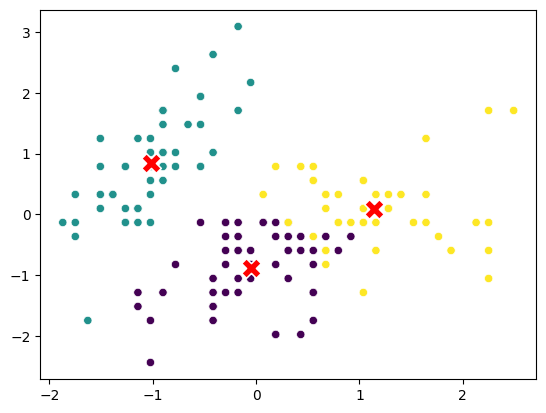

In [10]:
# Kmeans

kmeans = KMeans(n_clusters=3, n_init=10, random_state=10) 
labels = kmeans.fit_predict(pca_data) 

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels) 
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="X", c="red", s=200)